<a href="https://colab.research.google.com/github/RaghadJathmi/Preprocessing-of-License-Plate-Image-Quality-/blob/main/Preprocessing_and_Enhancement_of_License_Plate_Image_Quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Import Libraries**

In [ ]:
import os
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt

**Load Images**

In [ ]:
dataset_path = "/content/drive/MyDrive/Car Plate Number.coco/train"

In [ ]:
image_extensions = ['*.jpg', '*.jpeg', '*.png']

image_paths = []

for ext in image_extensions:

    image_paths.extend(
        glob.glob(
            os.path.join(dataset_path, '**', ext),
            recursive=True
        )
    )

print("Total Images Found:", len(image_paths))

print("Images To Process:", len(image_paths))

Total Images Found: 99
Images To Process: 99


**Create Output Folders**

In [ ]:
output_dir = "/content/drive/MyDrive/Plate_Results"

steps = [
    "original",
    "grayscale",
    "blur",
    "clahe",
    "sharpen",
    "threshold",
    "opening",
    "closing",
    "contour"
]

for step in steps:

    os.makedirs(
        os.path.join(output_dir, step),
        exist_ok=True
    )

print("Folders Created Successfully")

Folders Created Successfully


**Mine Pipeline**

In [ ]:
for idx, image_path in enumerate(image_paths):

    print(f"Processing {idx+1}/{len(image_paths)}")

    # Read Image
    image = cv2.imread(image_path)

    if image is None:
        continue

    filename = f"img_{idx}.png"

    # Original
    cv2.imwrite(
        os.path.join(output_dir, "original", filename),
        image
    )

    # Grayscale
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    cv2.imwrite(
        os.path.join(output_dir, "grayscale", filename),
        gray
    )

    # Gaussian Blur
    blur = cv2.GaussianBlur(
        gray,
        (5,5),
        0
    )

    cv2.imwrite(
        os.path.join(output_dir, "blur", filename),
        blur
    )

    # CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    ).apply(blur)

    cv2.imwrite(
        os.path.join(output_dir, "clahe", filename),
        clahe
    )

    # Unsharp masking
    gaussian = cv2.GaussianBlur(
        clahe,
        (9,9),
        10.0
    )

    unsharp = cv2.addWeighted(
        clahe,
        1.5,
        gaussian,
        -0.5,
        0
    )

    cv2.imwrite(
        os.path.join(output_dir, "sharpen", filename),
        unsharp
    )

    # OTSU THRESHOLD (INVERTED)
    _, thresh = cv2.threshold(
    unsharp,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    cv2.imwrite(
        os.path.join(output_dir, "threshold", filename),
        thresh
    )

    # Morphological Opening
    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (3,3)
    )

    opening = cv2.morphologyEx(
        thresh,
        cv2.MORPH_OPEN,
        kernel
    )

    cv2.imwrite(
        os.path.join(output_dir, "opening", filename),
        opening
    )

    # Morphological Closing
    closing = cv2.morphologyEx(
        opening,
        cv2.MORPH_CLOSE,
        kernel
    )

    cv2.imwrite(
        os.path.join(output_dir, "closing", filename),
        closing
    )

    # Contour Detection
    contours, _ = cv2.findContours(
        closing,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    contour_img = cv2.cvtColor(
        gray,
        cv2.COLOR_GRAY2BGR
    )

    for cnt in contours:

        area = cv2.contourArea(cnt)

        if area > 80:

            x, y, w, h = cv2.boundingRect(cnt)

            # Ignore tiny noise
            if h > 20 and w > 5:

                cv2.rectangle(
                    contour_img,
                    (x,y),
                    (x+w, y+h),
                    (0,255,0),
                    1
                )

    cv2.imwrite(
        os.path.join(output_dir, "contour", filename),
        contour_img
    )

print("\nProcessing Completed Successfully")

Processing 1/99
Processing 2/99
Processing 3/99
Processing 4/99
Processing 5/99
Processing 6/99
Processing 7/99
Processing 8/99
Processing 9/99
Processing 10/99
Processing 11/99
Processing 12/99
Processing 13/99
Processing 14/99
Processing 15/99
Processing 16/99
Processing 17/99
Processing 18/99
Processing 19/99
Processing 20/99
Processing 21/99
Processing 22/99
Processing 23/99
Processing 24/99
Processing 25/99
Processing 26/99
Processing 27/99
Processing 28/99
Processing 29/99
Processing 30/99
Processing 31/99
Processing 32/99
Processing 33/99
Processing 34/99
Processing 35/99
Processing 36/99
Processing 37/99
Processing 38/99
Processing 39/99
Processing 40/99
Processing 41/99
Processing 42/99
Processing 43/99
Processing 44/99
Processing 45/99
Processing 46/99
Processing 47/99
Processing 48/99
Processing 49/99
Processing 50/99
Processing 51/99
Processing 52/99
Processing 53/99
Processing 54/99
Processing 55/99
Processing 56/99
Processing 57/99
Processing 58/99
Processing 59/99
Proces

**Show Results**

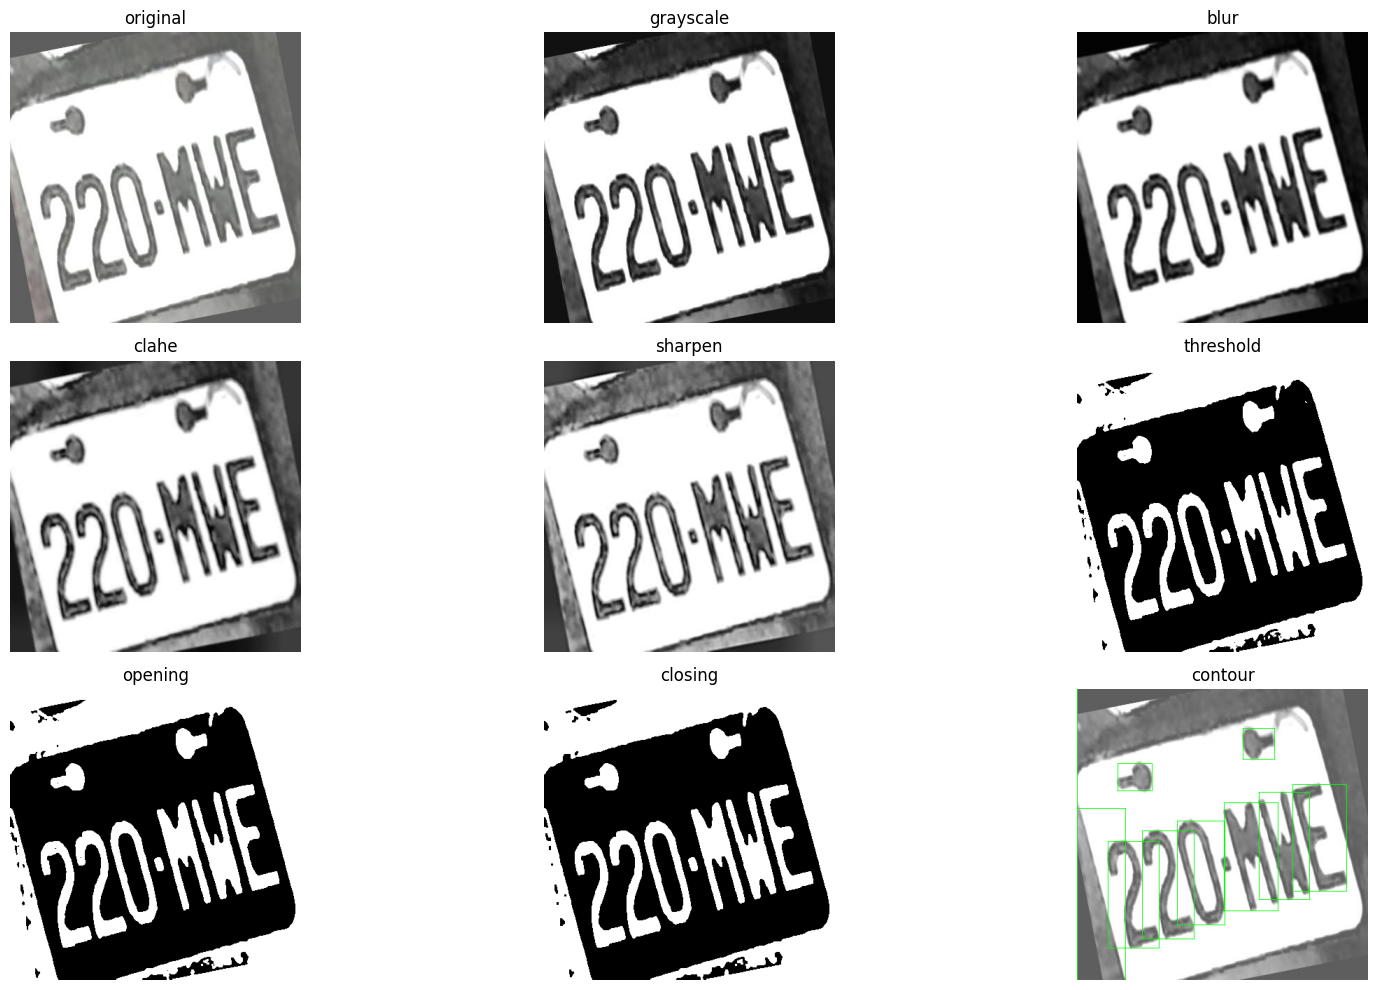

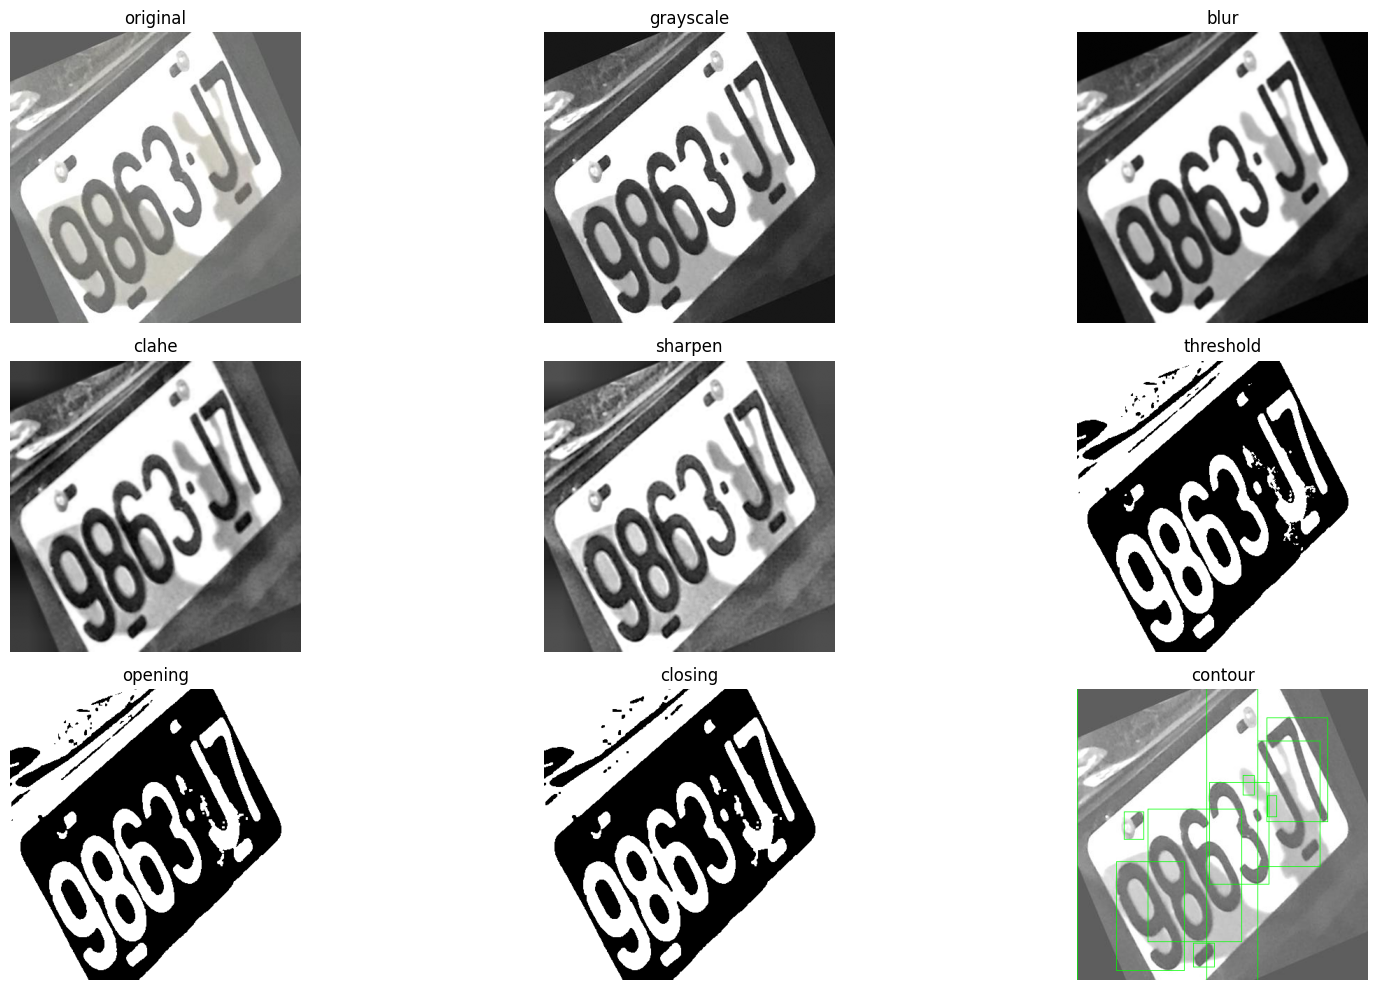

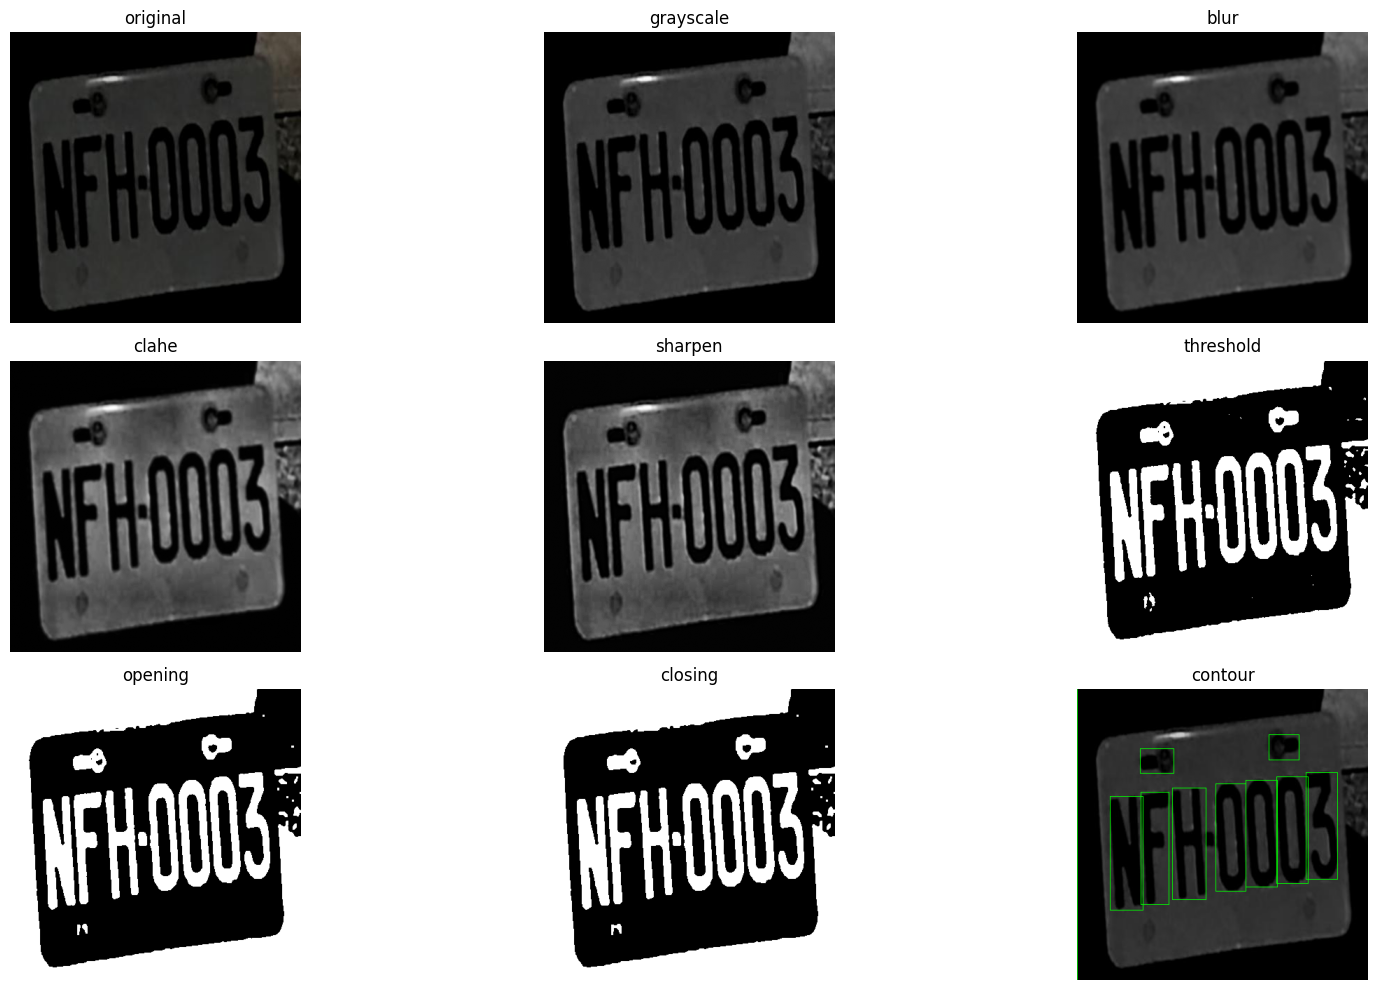

In [ ]:
for sample_index in range(3):

    filename = f"img_{sample_index}.png"

    plt.figure(figsize=(18,10))

    steps = [
        "original",
        "grayscale",
        "blur",
        "clahe",
        "sharpen",
        "threshold",
        "opening",
        "closing",
        "contour"
    ]

    for i, step in enumerate(steps):

        path = os.path.join(output_dir, step, filename)

        if step in ["original", "contour"]:

            img = cv2.imread(path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(3,3,i+1)
            plt.imshow(img)

        else:

            img = cv2.imread(path, 0)

            plt.subplot(3,3,i+1)
            plt.imshow(img, cmap='gray')

        plt.title(step)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

**Evaluation**

In [ ]:
!pip install scikit-image -q
import pandas as pd

from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity
)

In [ ]:
# CALCULATE PSNR & SSIM
results = []

psnr_values = []
ssim_values = []

for idx in range(len(image_paths)):

    filename = f"img_{idx}.png"

    # LOAD GRAYSCALE IMAGE
    gray = cv2.imread(
        os.path.join(output_dir, "grayscale", filename),
        0
    )

    # LOAD ENHANCED IMAGE
    # (UNSHARP RESULT)
    enhanced = cv2.imread(
        os.path.join(output_dir, "sharpen", filename),
        0
    )

    if gray is None or enhanced is None:
        continue

    # CALCULATE PSNR
    psnr = peak_signal_noise_ratio(
        gray,
        enhanced
    )

    # CALCULATE SSIM
    ssim = structural_similarity(
        gray,
        enhanced
    )

    # STORE RESULTS
    psnr_values.append(psnr)
    ssim_values.append(ssim)

    results.append([
        filename,
        round(psnr, 2),
        round(ssim, 4)
    ])

# CREATE DATAFRAME
df = pd.DataFrame(
    results,
    columns=["Image", "PSNR (dB)", "SSIM"]
)

# DISPLAY FIRST 10 RESULTS
print(df.head(10))

# AVERAGE METRICS
avg_psnr = np.mean(psnr_values)
avg_ssim = np.mean(ssim_values)

print(f"Average PSNR : {avg_psnr:.2f} dB")
print(f"Average SSIM : {avg_ssim:.4f}")

       Image  PSNR (dB)    SSIM
0  img_0.png      23.38  0.9025
1  img_1.png      21.39  0.8813
2  img_2.png      18.22  0.6302
3  img_3.png      20.22  0.8078
4  img_4.png      21.47  0.7689
5  img_5.png      20.60  0.8353
6  img_6.png      18.64  0.8270
7  img_7.png      24.50  0.9067
8  img_8.png      19.75  0.7908
9  img_9.png      18.62  0.8622
Average PSNR : 20.38 dB
Average SSIM : 0.7893


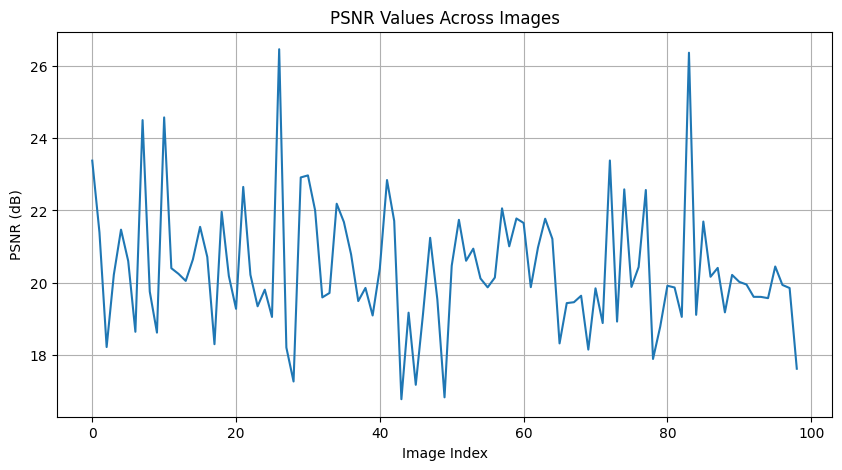

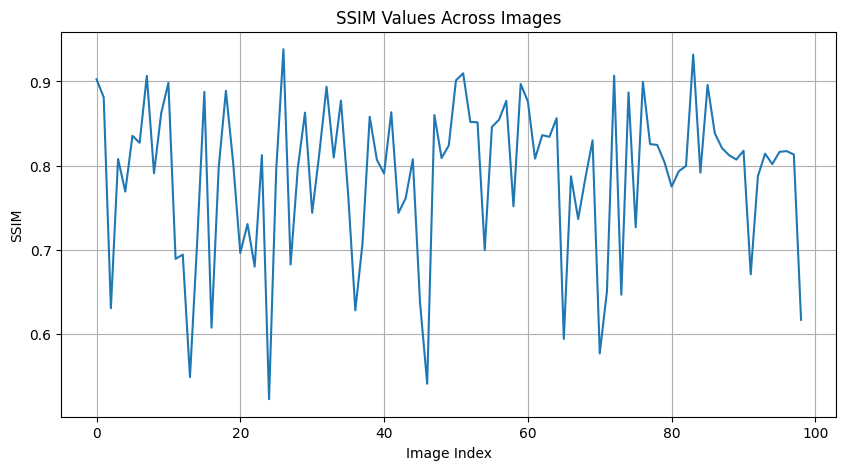

In [ ]:
# VISUALIZE METRICS
plt.figure(figsize=(10,5))

plt.plot(psnr_values)

plt.title("PSNR Values Across Images")

plt.xlabel("Image Index")

plt.ylabel("PSNR (dB)")

plt.grid(True)

plt.show()


plt.figure(figsize=(10,5))

plt.plot(ssim_values)

plt.title("SSIM Values Across Images")

plt.xlabel("Image Index")

plt.ylabel("SSIM")

plt.grid(True)

plt.show()